# 02 - Model Results

Compare baseline, strict classical CV, and ResNet50 temporal-head results.

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style='whitegrid')

In [2]:
summary_path = ROOT / 'artifacts/reports/model_summary.csv'
summary = pd.read_csv(summary_path).sort_values('macro_f1', ascending=False)
summary

,model,accuracy,macro_f1,weighted_f1,high_recall
0,deep_resnet50,0.622093,0.626039,0.623182,0.613636
1,classical_linear_svm,0.534884,0.537881,0.533295,0.636364
2,classical_random_forest,0.534884,0.535996,0.535157,0.500000
3,classical_logistic_regression,0.511628,0.511475,0.511517,0.522727
4,baseline,0.366279,0.249949,0.279013,0.000000


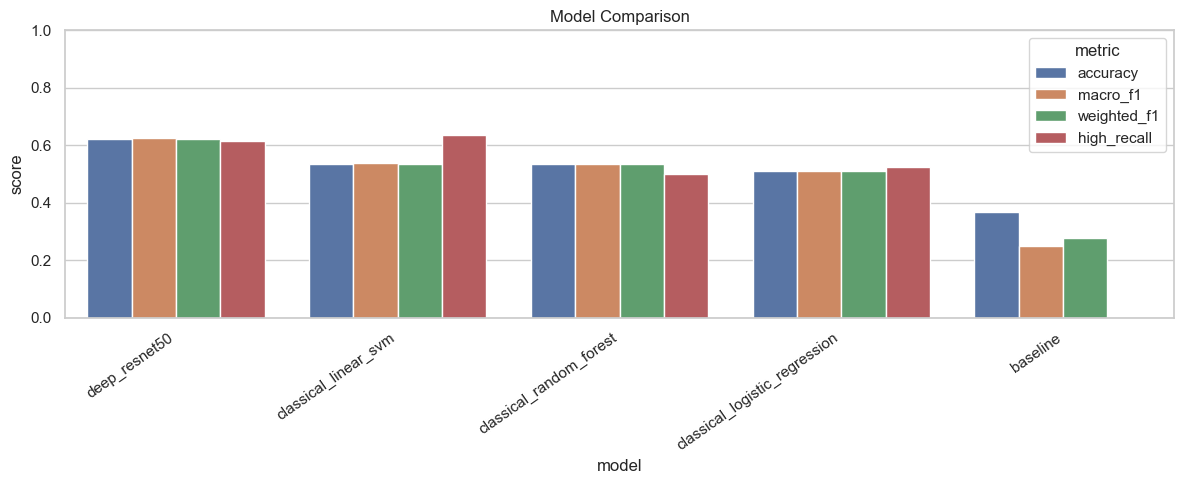

In [3]:
melted = summary.melt(id_vars='model', value_vars=['accuracy', 'macro_f1', 'weighted_f1', 'high_recall'], var_name='metric', value_name='score')
plt.figure(figsize=(12, 5))
sns.barplot(data=melted, x='model', y='score', hue='metric')
plt.xticks(rotation=35, ha='right')
plt.ylim(0, 1)
plt.title('Model Comparison')
plt.tight_layout()

Baseline


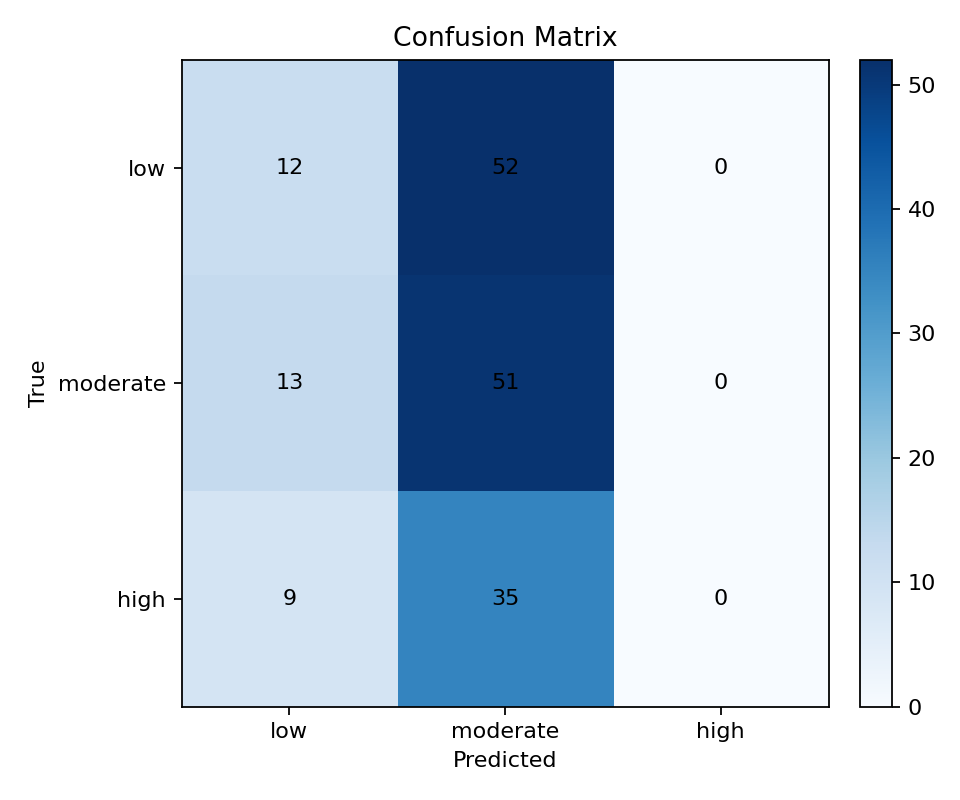

Best Classical CV


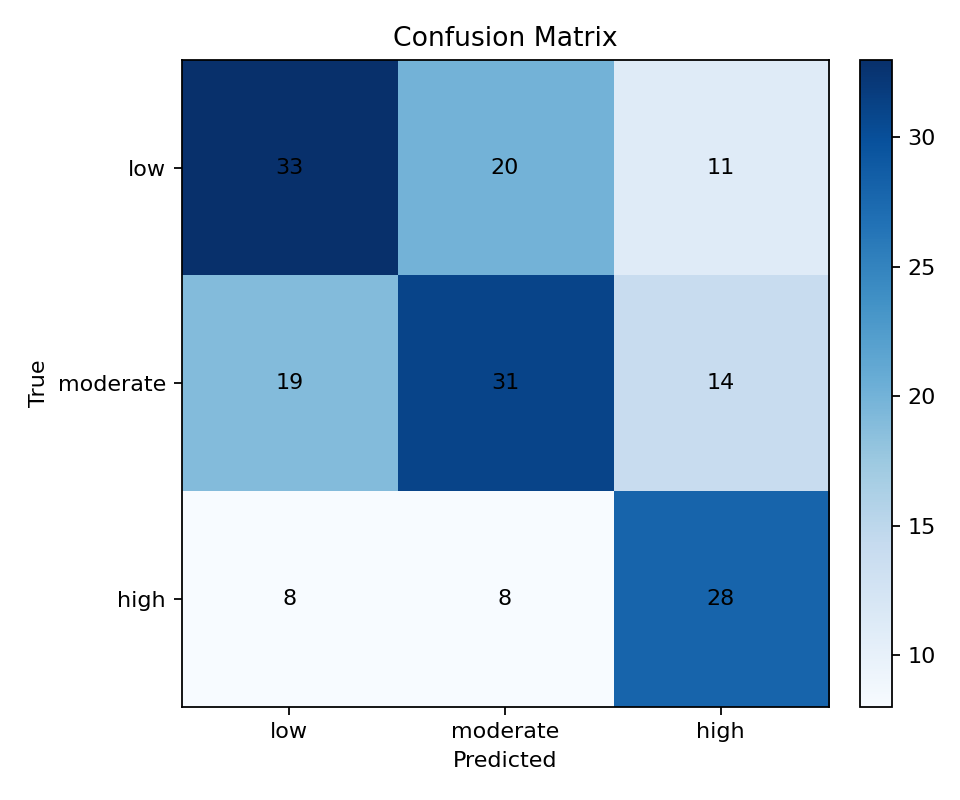

Deep ResNet50


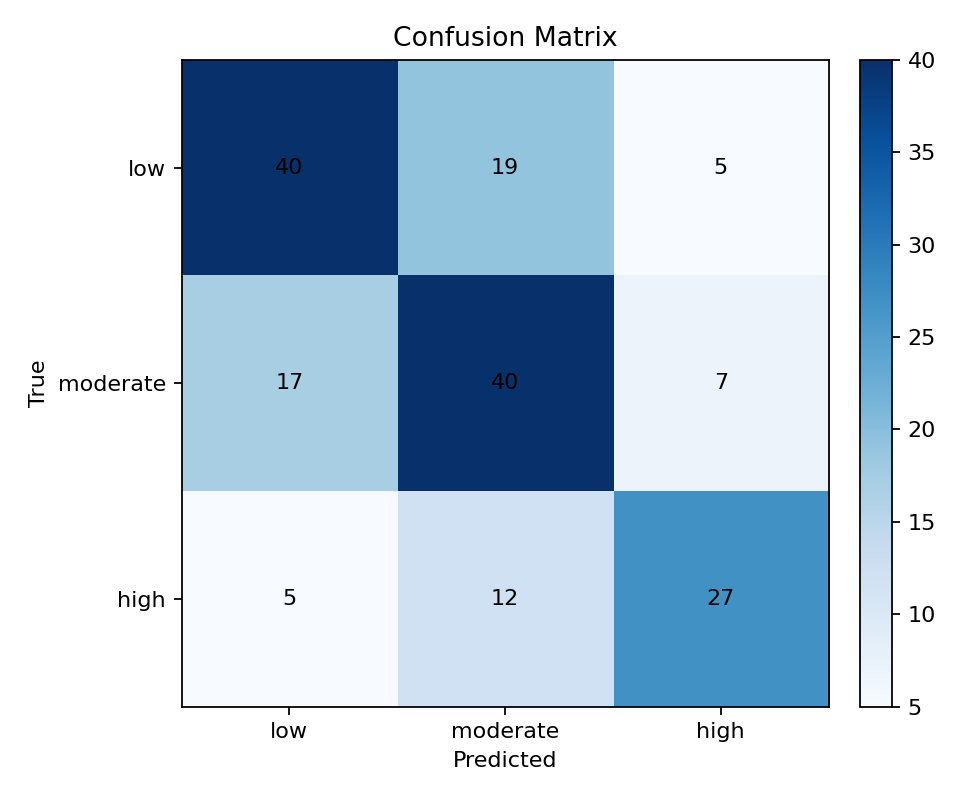

In [4]:
for title, path in {
    'Baseline': ROOT / 'artifacts/models/baseline/confusion_matrix.png',
    'Best Classical CV': ROOT / 'artifacts/models/classical/linear_svm_confusion_matrix.png',
    'Deep ResNet50': ROOT / 'artifacts/models/deep_resnet50/confusion_matrix.png',
}.items():
    print(title)
    display(Image(filename=str(path)))

## Light Transformation Experiment

This focused experiment compares deterministic light preprocessing choices rather than creating additional augmented samples. For the classical pipeline, it compares plain HOG + motion features with CLAHE contrast-normalized HOG + motion features. For the ResNet50 pipeline, it compares the best 4-frame setting with no transform, a slight brightness boost, mild contrast boost, and mild Gaussian blur before embedding extraction.


In [5]:
transform_summary = pd.read_csv(ROOT / 'artifacts/experiments/transformations/summary.csv')
transform_summary

,model,accuracy,macro_f1,weighted_f1,high_recall
0,deep_resnet50_mild_blur_4f,0.627907,0.633416,0.628648,0.659091
1,deep_resnet50_plain_4f,0.622093,0.628353,0.622964,0.636364
2,deep_resnet50_brightness_boost_4f,0.616279,0.623122,0.617124,0.636364
3,deep_resnet50_contrast_boost_4f,0.604651,0.607137,0.604722,0.613636
4,contrast_normalized_classical_linear_svm,0.540698,0.543907,0.539322,0.636364
5,contrast_normalized_classical_logistic_regression,0.540698,0.542748,0.540533,0.568182
6,plain_classical_linear_svm,0.534884,0.537881,0.533295,0.636364
7,plain_classical_random_forest,0.534884,0.535996,0.535157,0.500000
8,contrast_normalized_classical_random_forest,0.529070,0.530155,0.528874,0.522727
9,plain_classical_logistic_regression,0.511628,0.511475,0.511517,0.522727


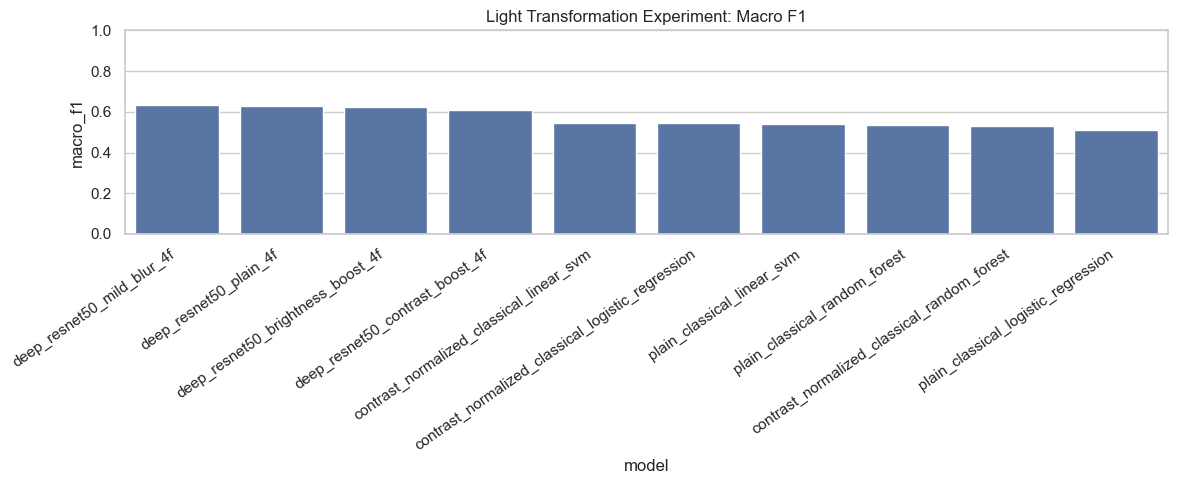

In [6]:
plt.figure(figsize=(12, 5))
sns.barplot(data=transform_summary, x='model', y='macro_f1')
plt.xticks(rotation=35, ha='right')
plt.ylim(0, 1)
plt.title('Light Transformation Experiment: Macro F1')
plt.tight_layout()


## Frame Count Experiment

Compare HOG + motion features and ResNet50 temporal-head models at 4, 8, 16, and 32 sampled frames per video. The best summary keeps the top classifier for each frame count and approach, while the full summary keeps every classical classifier candidate.

In [7]:
frame_dir = ROOT / 'artifacts/experiments/frame_count'
frame_summary = pd.read_csv(frame_dir / 'summary.csv')
frame_best = pd.read_csv(frame_dir / 'summary_best.csv')
frame_best.sort_values(['frames', 'approach'])

,frames,approach,model,accuracy,macro_f1,weighted_f1,high_recall
11,4,contrast_classical,random_forest,0.505814,0.494252,0.502111,0.363636
0,4,deep_resnet50,temporal_head,0.622093,0.628353,0.622964,0.636364
4,4,plain_classical,random_forest,0.558140,0.554090,0.557611,0.500000
8,8,contrast_classical,random_forest,0.529070,0.528799,0.528918,0.431818
2,8,deep_resnet50,temporal_head,0.616279,0.617985,0.616831,0.613636
5,8,plain_classical,random_forest,0.546512,0.547158,0.546827,0.500000
6,16,contrast_classical,linear_svm,0.540698,0.543907,0.539322,0.636364
1,16,deep_resnet50,temporal_head,0.622093,0.626039,0.623182,0.613636
7,16,plain_classical,linear_svm,0.534884,0.537881,0.533295,0.636364
10,32,contrast_classical,random_forest,0.500000,0.503078,0.500095,0.522727


In [8]:
frame_summary.sort_values(['frames', 'approach', 'model'])

,frames,approach,model,accuracy,macro_f1,weighted_f1,high_recall
18,4,contrast_classical,linear_svm,0.488372,0.493360,0.484953,0.636364
20,4,contrast_classical,logistic_regression,0.488372,0.490408,0.488624,0.500000
17,4,contrast_classical,random_forest,0.505814,0.494252,0.502111,0.363636
0,4,deep_resnet50,temporal_head,0.622093,0.628353,0.622964,0.636364
14,4,plain_classical,linear_svm,0.511628,0.513154,0.510033,0.613636
10,4,plain_classical,logistic_regression,0.534884,0.530204,0.534400,0.477273
4,4,plain_classical,random_forest,0.558140,0.554090,0.557611,0.500000
25,8,contrast_classical,linear_svm,0.465116,0.470749,0.460371,0.636364
21,8,contrast_classical,logistic_regression,0.482558,0.490073,0.483895,0.500000
12,8,contrast_classical,random_forest,0.529070,0.528799,0.528918,0.431818


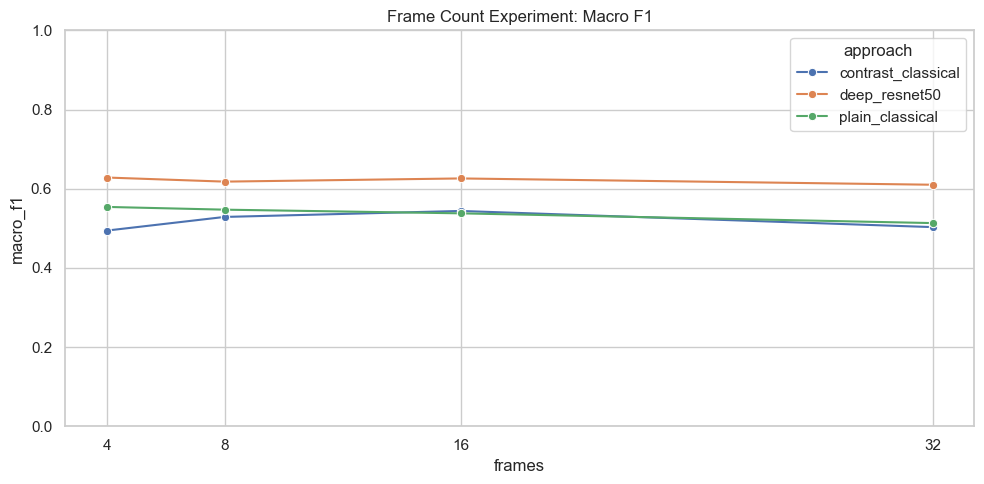

In [9]:
plot_data = frame_best.sort_values(['approach', 'frames'])
plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_data, x='frames', y='macro_f1', hue='approach', marker='o')
plt.xticks([4, 8, 16, 32])
plt.ylim(0, 1)
plt.title('Frame Count Experiment: Macro F1')
plt.tight_layout()
plt.savefig(ROOT / 'artifacts/reports/frame_count_macro_f1.png', dpi=160, bbox_inches='tight')

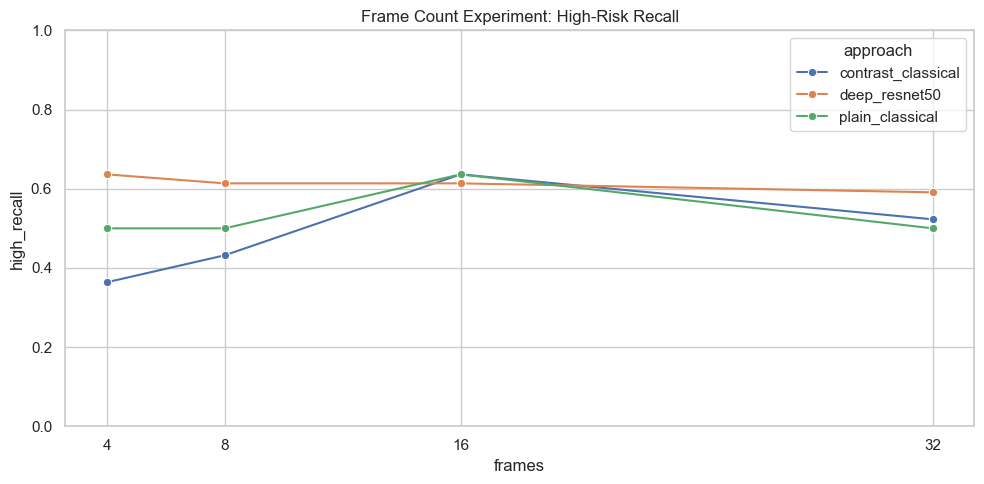

In [10]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_data, x='frames', y='high_recall', hue='approach', marker='o')
plt.xticks([4, 8, 16, 32])
plt.ylim(0, 1)
plt.title('Frame Count Experiment: High-Risk Recall')
plt.tight_layout()
plt.savefig(ROOT / 'artifacts/reports/frame_count_high_recall.png', dpi=160, bbox_inches='tight')

## Top Model Logits

The highest-performing model is the 4-frame ResNet50 temporal-head model. These are out-of-fold logits for each video, plus softmax probabilities for easier interpretation.

In [11]:
top_logits = pd.read_csv(ROOT / 'artifacts/reports/top_model_logits.csv')
top_logits

,video_id,risk_level,pred_risk_level,fold,logit_low,logit_moderate,logit_high,prob_low,prob_moderate,prob_high,prediction_confidence
0,VID_001,high,high,4,-2.477422,-1.268223,4.526708,0.000905,0.003031,0.996065,0.996065
1,VID_002,moderate,moderate,3,0.128443,1.292582,-1.373160,0.225941,0.723726,0.050334,0.723726
2,VID_003,moderate,moderate,2,0.160866,0.338728,-0.013659,0.329542,0.393691,0.276768,0.393691
3,VID_004,high,high,2,0.487626,-0.379210,0.864165,0.347522,0.146056,0.506421,0.506421
4,VID_005,high,high,2,0.310042,-1.103530,2.086962,0.139764,0.034001,0.826235,0.826235
...,...,...,...,...,...,...,...,...,...,...,...
167,VID_168,low,moderate,3,0.280779,1.780371,-1.548267,0.177292,0.794241,0.028467,0.794241
168,VID_169,low,low,0,0.965669,0.197251,-0.682803,0.603832,0.280025,0.116143,0.603832
169,VID_170,low,moderate,4,-0.199251,3.600975,-4.384558,0.021869,0.977798,0.000333,0.977798
170,VID_171,low,moderate,2,0.286320,1.076480,-1.601888,0.298054,0.656837,0.045108,0.656837


In [12]:
top_logits.sort_values('prediction_confidence').head(15)

,video_id,risk_level,pred_risk_level,fold,logit_low,logit_moderate,logit_high,prob_low,prob_moderate,prob_high,prediction_confidence
126,VID_127,low,low,0,0.740451,0.648286,0.609056,0.358574,0.327003,0.314423,0.358574
17,VID_018,high,high,1,0.643402,0.635807,0.776936,0.318949,0.316536,0.364514,0.364514
18,VID_019,high,low,1,0.762741,0.667371,0.505933,0.372779,0.338870,0.288351,0.372779
2,VID_003,moderate,moderate,2,0.160866,0.338728,-0.013659,0.329542,0.393691,0.276768,0.393691
59,VID_060,low,moderate,1,0.579455,0.675393,-0.004290,0.376152,0.414028,0.209820,0.414028
44,VID_045,low,low,1,0.731106,0.702422,-0.175347,0.420932,0.409030,0.170038,0.420932
19,VID_020,moderate,moderate,3,0.266443,0.573107,0.046100,0.316343,0.429873,0.253784,0.429873
55,VID_056,high,low,0,0.626368,0.397235,-0.081551,0.437084,0.347579,0.215337,0.437084
68,VID_069,moderate,moderate,2,0.261034,0.335129,-0.838086,0.414925,0.446837,0.138238,0.446837
100,VID_101,high,moderate,2,0.382397,0.460403,-0.795303,0.418565,0.452523,0.128912,0.452523


## Incorrect Prediction Logits

This table joins metadata with the 4-frame ResNet50 top-model logits and filters to videos where the predicted risk level does not match the labeled risk level.

In [13]:
metadata_cols = ['video_id', 'sport', 'impact_type', 'body_region', 'player_down']
metadata = pd.read_csv(ROOT / 'data/metadata.csv')
metadata = metadata.loc[:, ~metadata.columns.str.contains(r'^Unnamed')]

misprediction_logits = (
    top_logits
    .merge(metadata[metadata_cols], on='video_id', how='left')
    .query('risk_level != pred_risk_level')
    [[
        'video_id', 'sport', 'impact_type', 'body_region', 'player_down',
        'risk_level', 'pred_risk_level', 'fold',
        'logit_low', 'logit_moderate', 'logit_high',
        'prob_low', 'prob_moderate', 'prob_high', 'prediction_confidence',
    ]]
    .sort_values(['risk_level', 'pred_risk_level', 'video_id'])
)

misprediction_logits.to_csv(ROOT / 'artifacts/reports/top_model_misprediction_logits.csv', index=False)
misprediction_logits

,video_id,sport,impact_type,body_region,player_down,risk_level,pred_risk_level,fold,logit_low,logit_moderate,logit_high,prob_low,prob_moderate,prob_high,prediction_confidence
18,VID_019,hockey,collision,head_face,yes,high,low,1,0.762741,0.667371,0.505933,0.372779,0.338870,0.288351,0.372779
27,VID_028,hockey,object_hit,head_face,yes,high,low,1,1.156778,0.761706,-0.414256,0.531502,0.358036,0.110462,0.531502
37,VID_038,football,collision,head_face,yes,high,low,4,1.823946,-0.106957,-1.770274,0.852879,0.123682,0.023439,0.852879
55,VID_056,football,collision,head_face,yes,high,low,0,0.626368,0.397235,-0.081551,0.437084,0.347579,0.215337,0.437084
94,VID_095,soccer,collision,head_face,yes,high,low,3,0.816824,0.222381,-0.090370,0.511371,0.282211,0.206418,0.511371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,VID_125,soccer,collision,lower_body,yes,moderate,low,0,1.687312,-1.465169,1.095291,0.626585,0.026784,0.346631,0.626585
130,VID_131,hockey,collision,upper_body,yes,moderate,low,2,1.166261,-0.632242,0.361094,0.620132,0.102661,0.277207,0.620132
132,VID_133,hockey,collision,upper_body,yes,moderate,low,1,1.197128,1.059740,-0.781320,0.497533,0.433666,0.068801,0.497533
135,VID_136,hockey,collision,lower_body,yes,moderate,low,0,2.502517,0.766465,-2.409056,0.844897,0.148883,0.006219,0.844897


In [14]:
misprediction_logits.groupby(['risk_level', 'pred_risk_level']).size().reset_index(name='count')

,risk_level,pred_risk_level,count
0,high,low,9
1,high,moderate,7
2,low,high,6
3,low,moderate,20
4,moderate,high,5
5,moderate,low,18
